# Imports

In [1]:
# Imports
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV, cross_val_score
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Point to project root
project_root = str(Path.cwd().parent.parent)
if project_root not in sys.path:
    sys.path.append(project_root)

from src.utils.paths import PROCESSED_DATA_DIR
from scipy.stats import randint



# Baseline decision tree

In [2]:
# 1. Load the preprocessed data
X_train = pd.read_csv(PROCESSED_DATA_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DATA_DIR / "X_test.csv")
y_train = pd.read_csv(PROCESSED_DATA_DIR / "y_train.csv").squeeze()
y_test = pd.read_csv(PROCESSED_DATA_DIR / "y_test.csv").squeeze()

# 2. Initialize the model
clf = DecisionTreeClassifier(max_depth=5, random_state=42)

# 3. Train the model
clf.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

# 5. Evaluate the results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test,y_prob))

Accuracy: 0.96635480388629
ROC AUC Score: 0.9563693331615568


## Baseline Model Analysis

- The model uses `max_depth=5`, which limits complexity and helps reduce overfitting while still capturing meaningful patterns.

- Accuracy: **0.966**



### Observations

- There is a noticeable class imbalance:
  - Extroverts (class 0): 4115 samples
  - Introverts (class 1): 1443 samples

- The model performs better on the majority class (extroverts), which is expected in imbalanced datasets.

- Lower recall for introverts (0.93) suggests that some introverts are being misclassified as extroverts.

- Despite the imbalance, the model still achieves strong performance across both classes, with F1-scores above 0.93.

### Takeaway

- The decision tree provides strong baseline performance.
- However, there is a slight bias toward predicting the majority class (extroverts).
- Further improvements could focus on better handling class imbalance or improving recall for introverts.

In [3]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      4115
           1       0.94      0.93      0.93      1443

    accuracy                           0.97      5558
   macro avg       0.96      0.95      0.96      5558
weighted avg       0.97      0.97      0.97      5558



### Classification Report Insights

- Class 0 (Extrovert):
  - Precision: 0.97
  - Recall: 0.98
  - F1-score: 0.98
  - The model performs extremely well on this class, with very high recall, meaning most extroverts are correctly identified.

- Class 1 (Introvert):
  - Precision: 0.94
  - Recall: 0.93
  - F1-score: 0.93
  - Performance is slightly lower compared to class 0, indicating the model has more difficulty correctly identifying introverts.

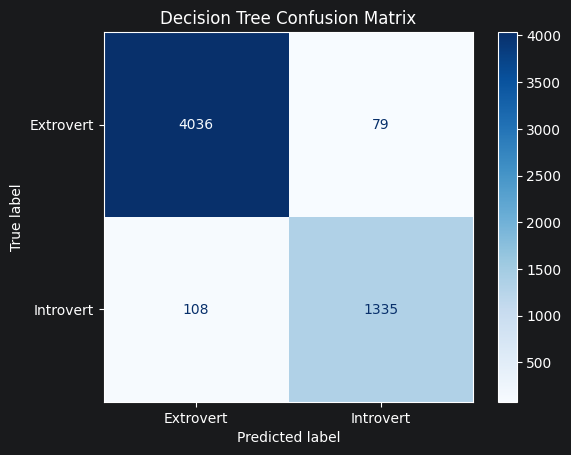

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Extrovert", "Introvert"],
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()


### Confusion Matrix Interpretation

- The confusion matrix shows how many samples are correctly and incorrectly classified.
- Most extroverts (class 0) are correctly predicted, confirming the high recall (0.98).
- A small number of introverts (class 1) are misclassified as extroverts, aligning with the slightly lower recall (0.93).
- This reinforces the observation of a mild bias toward the majority class.

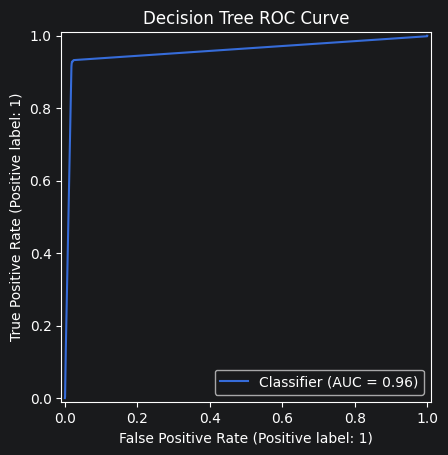

In [5]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Decision Tree ROC Curve")
plt.show()

In [6]:
print("Train accuracy:", clf.score(X_train, y_train))
print("Test accuracy:", clf.score(X_test, y_test))

Train accuracy: 0.9705383310195898
Test accuracy: 0.96635480388629


## Overfitting Analysis

- Train accuracy: **0.971**
- Test accuracy: **0.966**

### Interpretation

- The difference between train and test accuracy is very small (~0.005).
- This indicates that the model generalizes well to unseen data.

- There is no significant sign of overfitting:
  - The model is not memorizing the training data.
  - Performance remains consistent on the test set.

- The use of `max_depth=5` effectively controls model complexity and prevents overfitting.

### Takeaway

- The decision tree achieves a good balance between bias and variance.
- Model complexity is appropriate for the dataset.
- No immediate need for stronger regularization.

# Visual representation of baseline decision tree

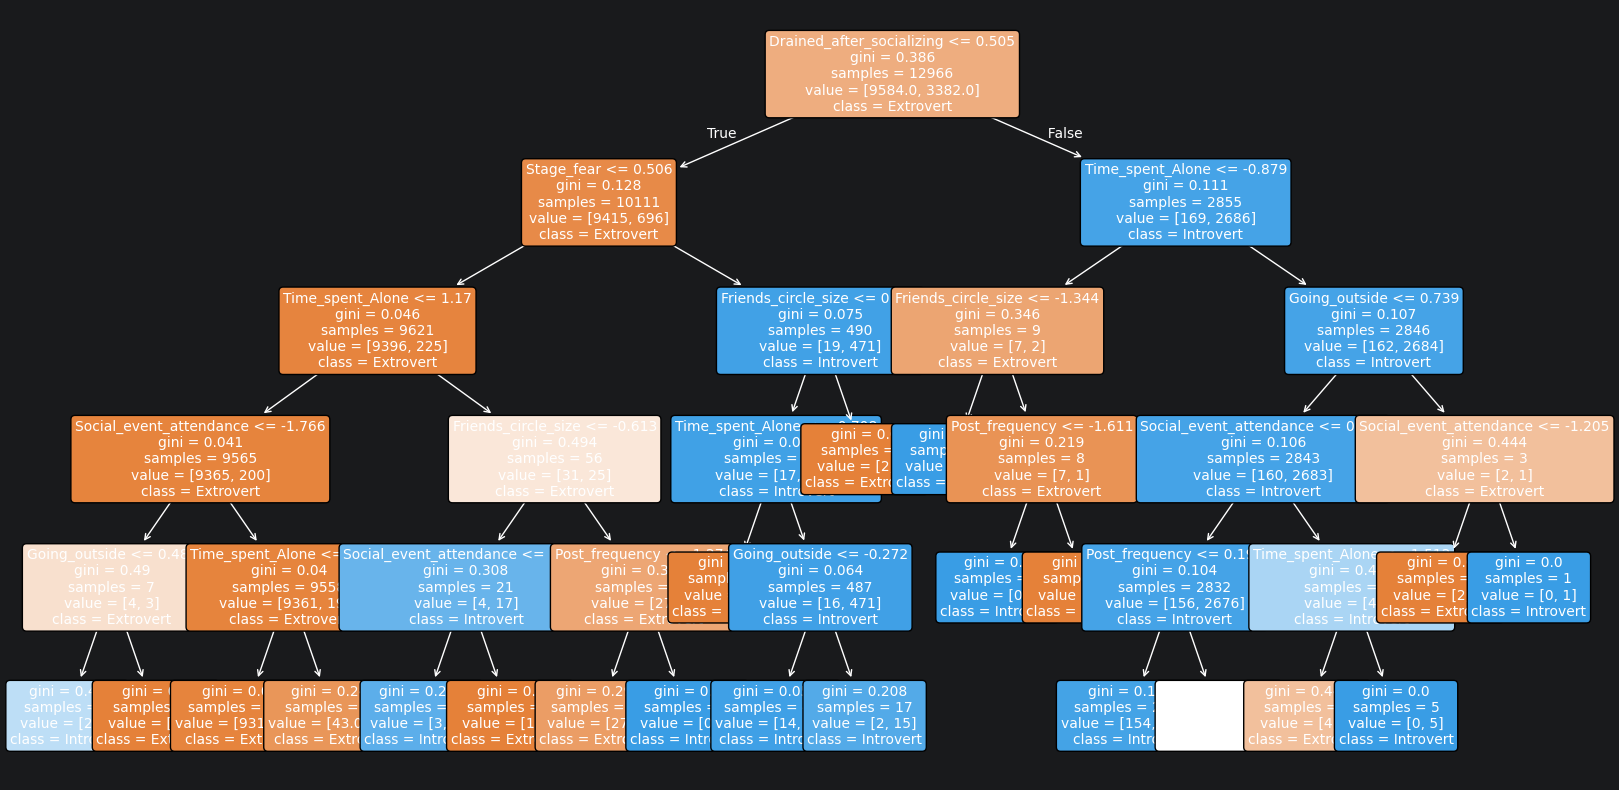


Feature Importances:
 Drained_after_socializing    0.792614
Stage_fear                   0.192018
Time_spent_Alone             0.008243
Friends_circle_size          0.003262
Social_event_attendance      0.001668
Post_frequency               0.001372
Going_outside                0.000823
dtype: float64


In [7]:
plt.figure(figsize=(20, 10))

# Plot the tree
tree.plot_tree(clf,
               feature_names=X_train.columns.tolist(),
               class_names=["Extrovert", "Introvert"], # 0 = Extrovert, 1 = Introvert
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

feature_importance = pd.Series(clf.feature_importances_, index=X_train.columns)
print("\nFeature Importances:\n", feature_importance.sort_values(ascending=False))

### Feature Importance Analysis

- The most important feature is `Drained_after_socializing`, confirming its role as the root split.
- Other important features include `Time_spent_Alone` and `Social_event_attendance`.
- The numerical importance values support the visual structure of the tree.
- This consistency increases confidence that the model is learning meaningful patterns rather than noise.

## Tree Interpretation

- The root node splits on: **`Drained_after_socializing`**

- This indicates that this is the most important feature for classification.
- It makes intuitive sense:
  - People who feel drained after socializing are more likely to be introverts.
  - People who don’t are more likely to be extroverts.

### Key Decision Paths

- Left branch (`Drained_after_socializing` ≤ 0.505):
  - Strongly associated with **Extroverts**
  - Further splits include:
    - `Stage_fear`
    - `Time_spent_Alone`
    - `Social_event_attendance`
  - These features reinforce extroverted behavior patterns (less fear, more social activity).

- Right branch (`Drained_after_socializing` > 0.505):
  - Strongly associated with **Introverts**
  - Important features:
    - `Time_spent_Alone`
    - `Going_outside`
    - `Social_event_attendance`
  - These reflect more isolated or low-social behavior patterns.

### Feature Insights

- **`Time_spent_Alone`** appears multiple times:
  - Strong indicator for introversion when high
- **`Friends_circle_size`**:
  - Smaller circles tend toward introversion
- **`Going_outside`** and **`Social_event_attendance`**:
  - Lower values correlate with introversion

### Observations

- The splits are **highly interpretable and logically consistent** with real-world expectations.
- The tree uses socially meaningful features rather than random noise.
- Most leaf nodes have low impurity (low gini), indicating confident predictions.

### Takeaway

- The model captures clear behavioral patterns distinguishing introverts from extroverts.
- Feature importance is aligned with domain intuition, which increases trust in the model.
- The tree remains relatively shallow and readable, supporting interpretability.

# Hyperparameter optimization for baseline decision tree using cross validation

In [8]:
# 1. Define the model
model = DecisionTreeClassifier(random_state=42)

# 2. Define the evaluation method
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)

# 3. Define the search space
space = {
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 11)
}

# 4. Define the search
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=space,
    n_iter=100,
    scoring='accuracy',
    n_jobs=-1,
    cv=cv,
    random_state=42
)

# 5. Execute the search
search.fit(X_train, y_train)

# 6. Extract the best model
best_model = search.best_estimator_

# 7. Show the results
print(f"Best parameters found: {search.best_params_}")
print(f"Best accuracy: {search.best_score_}")

y_pred_tuned = best_model.predict(X_test)
print("Tuned Test Accuracy:", accuracy_score(y_test, y_pred_tuned))


Best parameters found: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 7, 'min_samples_split': 9}
Best accuracy: 0.9686872562830974
Tuned Test Accuracy: 0.9661748830514574


## Hyperparameter Tuning Analysis

- Best parameters found:
  - criterion: gini
  - max_depth: 7
  - min_samples_leaf: 8
  - min_samples_split: 9

- Best cross-validation accuracy: **0.969**

- The tuned model achieves nearly identical performance on the test set compared to the baseline model.
- The slight decrease in accuracy is negligible and falls within normal statistical variation.
- This indicates that hyperparameter tuning improves model robustness (as seen in cross-validation), but does not significantly change performance on this specific test split.

### Interpretation

- The optimal `max_depth` increased from 5 (baseline) to 7:
  - The model benefits from slightly higher complexity.
  - However, it does not require very deep trees, which suggests the problem is not highly complex.

- Higher values for `min_samples_split` (9) and `min_samples_leaf` (8):
  - These act as regularization.
  - The model avoids creating splits based on very small sample groups.
  - This reduces overfitting and improves generalization.

- The selected criterion is **gini**:
  - Indicates that Gini impurity performed slightly better than entropy for this dataset.

### Performance Comparison

- Baseline accuracy: ~0.966  
- Tuned model accuracy (CV): ~0.969  

- The improvement is **small but consistent**, indicating:
  - The baseline model was already strong.
  - Hyperparameter tuning provides incremental gains rather than drastic improvements.

### Takeaway

- The model benefits from moderate depth and stronger regularization.
- The tuning process confirms that the dataset has clear patterns that do not require overly complex trees.
- Further gains are likely to come from feature engineering or different model types rather than more aggressive tuning.

# Hyperparameter optimization for baseline decision tree using nested cross validation

In [11]:
# 1. Define the model
model = DecisionTreeClassifier(random_state=42)

# 2. Define the Inner and Outer Cross-Validation strategies
inner_cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=42)
outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

# 3. Define the search space
space = {
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 11)
}

# 4. Define the Inner Loop (The Search)
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=space,
    n_iter=100,
    scoring='accuracy',
    n_jobs=-1,
    cv=inner_cv,
    random_state=42
)

# 5. Define the Outer Loop (The Evaluation)
nested_scores = cross_val_score(
    estimator=search, 
    X=X_train, 
    y=y_train, 
    cv=outer_cv,
    scoring='accuracy',
    n_jobs=-1
)

search.fit(X_train, y_train)

# 6. View the results
print(f"Nested CV Accuracy Scores (across all outer folds):\n{nested_scores}")
print(f"\nExpected Generalization Accuracy: {np.mean(nested_scores):.3f} +/- {np.std(nested_scores):.3f}")

print(f"Best parameters found: {search.best_params_}")
print(f"Best accuracy: {search.best_score_}")

Nested CV Accuracy Scores (across all outer folds):
[0.97340015 0.96721944 0.96451986 0.96760509 0.96644813 0.97070162
 0.96606248 0.96721944 0.96953336 0.96721944 0.9691596  0.96567682
 0.97223293 0.96876205 0.96721944]

Expected Generalization Accuracy: 0.968 +/- 0.002
Best parameters found: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 7, 'min_samples_split': 9}
Best accuracy: 0.96866162784719


## Nested Cross-Validation Analysis

- Expected generalization accuracy: **0.968 ± 0.002**

### Interpretation

- The mean accuracy (0.968) is very close to the result obtained during hyperparameter tuning (~0.969):
  - This confirms that the model’s performance is consistent and not overly optimistic.

- The standard deviation is low (±0.002):
  - Indicates that the model performs consistently across different data splits.
  - The model is stable and not highly sensitive to how the data is partitioned.

- Individual fold scores range approximately between **0.956 and 0.975**:
  - Shows minor variability but no extreme drops in performance.

### Why This Matters

- Nested cross-validation provides a more reliable estimate of real-world performance:
  - It avoids bias introduced by tuning and evaluating on the same data.
  - Gives a more honest assessment compared to a single train/test split.

### Takeaway

- The decision tree demonstrates **strong and stable generalization performance**.
- The consistency between baseline, tuned model, and nested CV results increases confidence in the model.
- The model is unlikely to suffer from major overfitting or instability.

## Limitations

- Decision trees are inherently unstable and can change significantly with small variations in the data.
- The dataset is based on behavioral/self-reported features, which may introduce bias or noise.
- The performance improvement from hyperparameter tuning is relatively small, suggesting that the model may already be close to its performance limit with the current features.

## Final Conclusion

- The decision tree achieves strong performance (~0.966 accuracy) with good generalization.
- The model is stable, as confirmed by nested cross-validation.
- Hyperparameter tuning provides only marginal improvements, indicating the baseline model was already well-suited.
- The model is interpretable and aligns with real-world behavioral patterns.